In [24]:
import numpy as np
import datasets
from datasets import load_dataset
import pandas as pd
import altair as alt
import numpy as np
import altair_saver
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from IPython.display import Image
from helper_funks import show_me_more, compute_scores


<h1>Initial data analysis

In [2]:
# Load our dataset
ds = load_dataset("trl-lib/tldr")
ds

DatasetDict({
    train: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 116722
    })
    validation: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 6447
    })
    test: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 6553
    })
})

In [3]:
# Looking at the training, test and validation data to examine them
training = pd.read_excel(open('diverse/subsets.xlsx', 'rb'), sheet_name='Train')
testing = pd.read_excel(open('diverse/subsets.xlsx', 'rb'), sheet_name='Test')
validation = pd.read_excel(open('diverse/subsets.xlsx', 'rb'), sheet_name='Validation')

In [4]:
# showing the amount of posts in each subreddit (category) in the training set
bar = show_me_more(training, "Train data", 'bluepurple')
bar.display()

alt.LayerChart(...)

In [5]:
# showing the amount of posts in each subreddit (category) in the test set
bar = show_me_more(testing, "Test data", 'greenblue')
bar.display()

alt.LayerChart(...)

In [6]:
# showing the amount of posts in each subreddit (category) in the validation set
bar = show_me_more(validation, "Validation data", 'orangered', False)
bar.display()

alt.LayerChart(...)

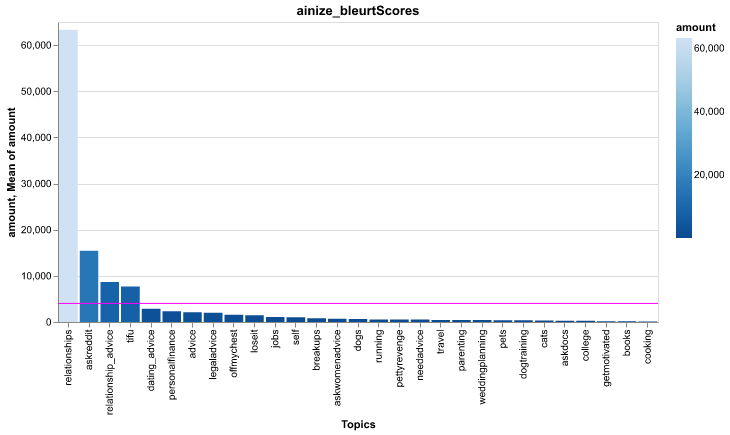

In [7]:
# TEST FOR HAND IN

alt.renderers.enable('jupyterlab')
alt.data_transformers.disable_max_rows()
source = pd.DataFrame(training)    
bar = show_me_more(source, "ainize_bleurtScores", 'blues')

bar.save("plots/TEST.png")
Image("plots/TEST.png")

This initial data analysis just shows the distribution of posts and summaries on the different subreddits. We chose to evaluate 114 different posts and summaries from each subreddits, as there are 114 posts in the subreddit "r/cooking" which is the subreddit with the fewest posts. This way we get the largest amount of posts while still having all subreddits equally represented.

<h2>Preliminary model evaluation and metrics analysis

In [ ]:
#Import the TL;DR dataset.
posts = load_dataset("trl-lib/tldr")

In [ ]:
#Method for getting the subreddit from the prompt text.
def getSubredditFromPost(post):
    return  post['prompt'].split('\n')[0][11:];

#Get all subreddits and the amount of posts present within each subreddit.
counts = {}
subreddits = []
for post in posts['train']:
    subreddit = getSubredditFromPost(post)
    if subreddit not in subreddits:
        subreddits.append(subreddit)
    if(subreddit in counts):
        counts[subreddit] = counts[subreddit] + 1
    else:
        counts[subreddit] = 1

#To ensure equal representation of subreddits we evaluate the same amount of posts from each subreddit. 
#That means we will take the amount of posts in the subreddit that has fewest posts and evaluate this 
#amount of posts for each subreddit.
amount_of_posts_to_evaluate = min(counts.values())


In [ ]:
import time
import evaluate
from helper_funks import NOIR

#Load the rouge and bleurt metric for evaluation.
rouge = evaluate.load("rouge")
bleurt = evaluate.load("bleurt", module_type="metric")
bertscore = evaluate.load("bertscore")
bleu = evaluate.load("bleu")

#Compute the NOIR, bleurt and rouge scores for the given pipeline.
def compute_scores(pipe, model_name):
  noirScores = {}
  bleurtScores = {}
  rougeScores = {}
  bertScores = {}
  bleuScores = {}

  promtsAndSummaries = {"prompt": [], model_name: []}
  for subreddit in subreddits:
    start = time.time()

    noirScores[subreddit] = []

    #Get the prompts and the labels of the given subreddit.
    sub_dataset = posts.filter(lambda post : getSubredditFromPost(post) == subreddit)['train'].select(range(amount_of_posts_to_evaluate))
    sub_dataset_prompts = [p['prompt'] for p in sub_dataset]
    labels = [p['completion'] for p in sub_dataset]
    
    #Generate the summaries from the given pipeline.
    generatedTexts = [text['summary_text'] for text in pipe(sub_dataset_prompts)]
    #Compute the NOIR score for each summary
    for prompt, generatedText in zip(sub_dataset_prompts, generatedTexts):
      promtsAndSummaries["prompt"].append(prompt)
      promtsAndSummaries[model_name].append(generatedText)
      
      noirScore = NOIR(prompt, generatedText)
      noirScores[subreddit].append(noirScore)
    
    #Compute the BLEURT score for each summary
    bleurtScore = bleurt.compute(predictions=generatedTexts, references=labels)
    bleurtScores[subreddit] = bleurtScore['scores']

    #Compute the average ROUGE-1, ROUGE-2, ROUGE-L and ROUGE-Lsum for the generated summaries.
    rougeScore = rouge.compute(predictions=generatedTexts, references=labels)
    rougeScores[subreddit] = rougeScore

    #Compute the BERT Score for each summary
    bertScore = bertscore.compute(predictions=generatedTexts, references=labels, lang='en')
    bertScores[subreddit] = bertScore

    #Compute the BLEU Score for each summary
    bleuScore = bleu.compute(predictions=generatedTexts, references=labels)
    bleuScores[subreddit] = bleuScore

    print(subreddit + " time: " + str(time.time()-start))

  return noirScores, bleurtScores, rougeScores, bertScores, bleuScores, promtsAndSummaries


In [ ]:
# Store all the given prompts and summaries in the end of the summaries file.
import pandas as pd
def storePromptsAndSummaries(promtsAndSummaries):
    try:
        original_df = pd.read_csv("./summaries.csv")
    except:
        original_df = pd.DataFrame({"prompt": []})
    new_df = pd.DataFrame({k: v for k, v in promtsAndSummaries.items()})
    final_df = pd.merge(original_df, new_df, on='prompt', how='outer')
    final_df.to_csv('./summaries.csv', index=False)
    

In [ ]:
#Evaluate the bart base model from ainize
from transformers import pipeline
ainize_noirScores, ainize_bleurtScores, ainize_rougeScores, ainize_bertScores, ainize_bleuScores, promtsAndSummaries = compute_scores(pipeline("summarization", model="ainize/bart-base-cnn", device=0), "ainize/bart-base-cnn")
storePromptsAndSummaries(promtsAndSummaries)


In [ ]:
#Save the scores to a csv and a json file.
import pandas as pd
from transformers import pipeline
df = pd.DataFrame(ainize_noirScores)
df.to_json('ainize_noirScores.json', index=False)
df.to_csv('ainize_noirScores.csv', index=False)
df = pd.DataFrame(ainize_bleurtScores)
df.to_json('ainize_bleurtScores.json', index=False)
df.to_csv('ainize_bleurtScores.csv', index=False)
df = pd.DataFrame(ainize_rougeScores)
df.to_json('ainize_rougeScores.json', index=False)
df.to_csv('ainize_rougeScores.csv', index=False)
df = pd.DataFrame(ainize_bertScores)
df.to_json('ainize_bertScores.json', index=False)
df.to_csv('ainize_bertScores.csv', index=False)
df = pd.DataFrame(ainize_bleuScores)
df.to_json('ainize_bleuScores.json', index=False)
df.to_csv('ainize_bleuScores.csv', index=False)

In [ ]:
#Evaluate the t5-small model from falconsai.
from transformers import pipeline
falconsai_noirScores, falconsai_bleurtScores, falconsai_rougeScores, falconsai_bertScores, falconsai_bleuScores, promtsAndSummaries = compute_scores(pipeline("summarization", model="Falconsai/text_summarization", device=0), "Falconsai/text_summarization")
storePromptsAndSummaries(promtsAndSummaries)

In [ ]:
#Save the scores to a csv and a json file.
import pandas as pd
df = pd.DataFrame(falconsai_noirScores)
df.to_json('falconsai_noirScores.json', index=False)
df.to_csv('falconsai_noirScores.csv', index=False)
df = pd.DataFrame(falconsai_bleurtScores)
df.to_json('falconsai_bleurtScores.json', index=False)
df.to_csv('falconsai_bleurtScores.csv', index=False)
df = pd.DataFrame(falconsai_rougeScores)
df.to_json('falconsai_rougeScores.json', index=False)
df.to_csv('falconsai_rougeScores.csv', index=False)
df = pd.DataFrame(falconsai_bertScores)
df.to_json('falconsai_bertScores.json', index=False)
df.to_csv('falconsai_bertScores.csv', index=False)
df = pd.DataFrame(falconsai_bleuScores)
df.to_json('falconsai_bleuScores.json', index=False)
df.to_csv('falconsai_bleuScores.csv', index=False)

In [ ]:
#Evaluate the pegasus large model from google
from transformers import pipeline
pipe = pipeline("summarization", model="google/pegasus-large", device=0)
pegasus_noirScores, pegasus_bleurtScores, pegasus_rougeScores, pegasus_bertScores, pegasus_bleuScores, promtsAndSummaries = compute_scores(pipe, "google/pegasus-large")
storePromptsAndSummaries(promtsAndSummaries)

In [ ]:
#Save the scores to a csv and a json file.
import pandas as pd
df = pd.DataFrame(pegasus_noirScores)
df.to_json('pegasus_noirScores.json', index=False)
df.to_csv('pegasus_noirScores.csv', index=False)
df = pd.DataFrame(pegasus_bleurtScores)
df.to_json('pegasus_bleurtScores.json', index=False)
df.to_csv('pegasus_bleurtScores.csv', index=False)
df = pd.DataFrame(pegasus_rougeScores)
df.to_json('pegasus_rougeScores.json', index=False)
df.to_csv('pegasus_rougeScores.csv', index=False)
df = pd.DataFrame(pegasus_bertScores)
df.to_json('pegasus_bertScores.json', index=False)
df.to_csv('pegasus_bertScores.csv', index=False)
df = pd.DataFrame(pegasus_bleuScores)
df.to_json('pegasus_bleuScores.json', index=False)
df.to_csv('pegasus_bleuScores.csv', index=False)

In [ ]:
#Evaluate the t5 large model from google
from transformers import pipeline
pipe = pipeline("summarization", model="google-t5/t5-large", device=0)
google_t5_noirScores, google_t5_bleurtScores, google_t5_rougeScores, google_t5_bertScores, google_t5_bleuScores, promtsAndSummaries = compute_scores(pipe, "google-t5/t5-large")
storePromptsAndSummaries(promtsAndSummaries)

In [ ]:
#Save the scores to a csv and a json file.
import pandas as pd
df = pd.DataFrame(google_t5_noirScores)
df.to_json('google_t5_noirScores.json', index=False)
df.to_csv('google_t5_noirScores.csv', index=False)
df = pd.DataFrame(google_t5_bleurtScores)
df.to_json('google_t5_bleurtScores.json', index=False)
df.to_csv('google_t5_bleurtScores.csv', index=False)
df = pd.DataFrame(google_t5_rougeScores)
df.to_json('google_t5_rougeScores.json', index=False)
df.to_csv('google_t5_rougeScores.csv', index=False)
df = pd.DataFrame(google_t5_bertScores)
df.to_json('google_t5_bertScores.json', index=False)
df.to_csv('google_t5_bertScores.csv', index=False)
df = pd.DataFrame(google_t5_bleuScores)
df.to_json('google_t5_bleuScores.json', index=False)
df.to_csv('google_t5_bleuScores.csv', index=False)

In [ ]:
#Evaluate the bart large model from google
from transformers import pipeline
pipe = pipeline("summarization", model="facebook/bart-large-cnn", device=0)
facebook_bart_noirScores, facebook_bart_bleurtScores, facebook_bart_rougeScores, facebook_bart_bertScores, facebook_bart_bleuScores, promtsAndSummaries = compute_scores(pipe, "facebook/bart-large-cnn")
storePromptsAndSummaries(promtsAndSummaries)

In [ ]:
#Save the scores to a csv and a json file.
import pandas as pd
df = pd.DataFrame(facebook_bart_noirScores)
df.to_json('facebook_bart_noirScores.json', index=False)
df.to_csv('facebook_bart_noirScores.csv', index=False)
df = pd.DataFrame(facebook_bart_bleurtScores)
df.to_json('facebook_bart_bleurtScores.json', index=False)
df.to_csv('facebook_bart_bleurtScores.csv', index=False)
df = pd.DataFrame(facebook_bart_rougeScores)
df.to_json('facebook_bart_rougeScores.json', index=False)
df.to_csv('facebook_bart_rougeScores.csv', index=False)
df = pd.DataFrame(facebook_bart_bertScores)
df.to_json('facebook_bart_bertScores.json', index=False)
df.to_csv('facebook_bart_bertScores.csv', index=False)
df = pd.DataFrame(facebook_bart_bleuScores)
df.to_json('facebook_bart_bleuScores.json', index=False)
df.to_csv('facebook_bart_bleuScores.csv', index=False)

<h1>Plotting the metrics<h1>

In the following cells, the plots for our initial analysis are shown. \
The naming convention for models in the folders with evaluations are as follows: \
Bart-Base: ainize \
Bart-Large: facebook_bart \
T5-small: falconsai \
T5-large: google_t5 \
Pegasus: pegasus

For an easier and faster plotting, the dataframes with evaluations for all models were given name in the form:
<h3>source_x_y<h3>


where x is the model and y is the metrics \
\
the values of x: \
1...BartBase: ainize \
2...Bart-Large: facebook_bart \
3...T5-small: falconsai \
4...T5-large: google_t5 \
5...Pegasus: pegasus \
\
the values of y: \
1...bert \
2...bleurt \
3...bleu \
4...noir \
5...rouge

In [8]:
# Bart-Base: Ainize
# getting the data as dataframe and reformating them so we can plot them
df_ainize_bert = pd.read_csv('evaluations/ainize_bertScores.csv')
df_ainize_bleurt = pd.read_csv('evaluations/ainize_bleurtScores.csv').melt(var_name='column')
df_ainize_bleu = pd.read_csv('evaluations/ainize_bleuScores.csv').melt(var_name='column')
df_ainize_noir = pd.read_csv('evaluations/ainize_noirScores.csv').melt(var_name='column')
df_ainize_rouge = pd.read_csv('evaluations/ainize_rougeScores.csv')

# change names of the dataframes for easy plotting
source_1_1 = pd.DataFrame(df_ainize_bert)
source_1_2 = pd.DataFrame(df_ainize_bleurt)
source_1_3 = pd.DataFrame(df_ainize_bleu)
source_1_4 = pd.DataFrame(df_ainize_noir)
source_1_5 = pd.DataFrame(df_ainize_rouge)

In [9]:
# Bart-Large: facebook_bart
# getting the data as dataframe and reformating them so we can plot them
df_bart_bert = pd.read_csv('evaluations/facebook_bart_bertScores.csv')
df_bart_bleurt = pd.read_csv('evaluations/facebook_bart_bleurtScores.csv').melt(var_name='column')
df_bart_bleu = pd.read_csv('evaluations/facebook_bart_bleuScores.csv').melt(var_name='column')
df_bart_noir = pd.read_csv('evaluations/facebook_bart_noirScores.csv').melt(var_name='column')
df_bart_rouge = pd.read_csv('evaluations/facebook_bart_rougeScores.csv')

# change names of the dataframes for easy plotting
source_2_1 = pd.DataFrame(df_bart_bert)
source_2_2 = pd.DataFrame(df_bart_bleurt)
source_2_3 = pd.DataFrame(df_bart_bleu)
source_2_4 = pd.DataFrame(df_bart_noir)
source_2_5 = pd.DataFrame(df_bart_rouge)

In [10]:
# T5-small: falconsai
# getting the data as dataframe and reformating them so we can plot them
df_falconsai_bert = pd.read_csv('evaluations/falconsai_bertScores.csv')
df_falconsai_bleurt = pd.read_csv('evaluations/falconsai_bleurtScores.csv').melt(var_name='column')
df_falconsai_bleu = pd.read_csv('evaluations/falconsai_bleuScores.csv').melt(var_name='column')
df_falconsai_noir = pd.read_csv('evaluations/falconsai_noirScores.csv').melt(var_name='column')
df_falconsai_rouge = pd.read_csv('evaluations/falconsai_rougeScores.csv')

# change names of the dataframes for easy plotting
source_3_1 = pd.DataFrame(df_falconsai_bert)
source_3_2 = pd.DataFrame(df_falconsai_bleurt)
source_3_3 = pd.DataFrame(df_falconsai_bleu)
source_3_4 = pd.DataFrame(df_falconsai_noir)
source_3_5 = pd.DataFrame(df_falconsai_rouge)

In [11]:
# T5-large: google_t5
# getting the data as dataframe and reformating them so we can plot them
df_t5_bert = pd.read_csv('evaluations/google_t5_bertScores.csv')
df_t5_bleurt = pd.read_csv('evaluations/google_t5_bleurtScores.csv').melt(var_name='column')
df_t5_bleu = pd.read_csv('evaluations/google_t5_bleuScores.csv').melt(var_name='column')
df_t5_noir = pd.read_csv('evaluations/google_t5_noirScores.csv').melt(var_name='column')
df_t5_rouge = pd.read_csv('evaluations/google_t5_rougeScores.csv')

# change names of the dataframes for easy plotting
source_4_1 = pd.DataFrame(df_t5_bert)
source_4_2 = pd.DataFrame(df_t5_bleurt)
source_4_3 = pd.DataFrame(df_t5_bleu)
source_4_4 = pd.DataFrame(df_t5_noir)
source_4_5 = pd.DataFrame(df_t5_rouge)

In [12]:
# Pegasus
# getting the data as dataframe and reformating them so we can plot them
df_pegasus_bert = pd.read_csv('evaluations/pegasus_bertScores.csv')
df_pegasus_bleurt = pd.read_csv('evaluations/pegasus_bleurtScores.csv').melt(var_name='column')
df_pegasus_bleu = pd.read_csv('evaluations/pegasus_bleuScores.csv').melt(var_name='column')
df_pegasus_noir = pd.read_csv('evaluations/pegasus_noirScores.csv').melt(var_name='column')
df_pegasus_rouge = pd.read_csv('evaluations/pegasus_rougeScores.csv')

# change names of the dataframes for easy plotting
source_5_1 = pd.DataFrame(df_pegasus_bert)
source_5_2 = pd.DataFrame(df_pegasus_bleurt)
source_5_3 = pd.DataFrame(df_pegasus_bleu)
source_5_4 = pd.DataFrame(df_pegasus_noir)
source_5_5 = pd.DataFrame(df_pegasus_rouge)

BertScores had to be converted, because the metrics is capturing both Recall and Precision, we are plotting the values for Precision

In [13]:
def convertToPrecision(df):
    result = {}
    for i in range(len(df.columns)):

        subreddit = df.columns[i]
        result[subreddit] = []

        listOfPrecisionString = df.iloc[0]
        for precision in listOfPrecisionString[i][1:-1].split(","):
            result[subreddit].append(precision)
    return pd.DataFrame(data=result)

df_ainize_bert = source_1_1
precision_ainize_bert = convertToPrecision(df_ainize_bert).melt(var_name='column')
precision_ainize_bert['value'] = precision_ainize_bert['value'].astype(float)

df_facebook_bart_bert = source_2_1
precision_facebook_bart_bert = convertToPrecision(df_facebook_bart_bert).melt(var_name='column')
precision_facebook_bart_bert['value'] = precision_facebook_bart_bert['value'].astype(float)

df_falconsai_bert = source_3_1
precision_falconsai_bert = convertToPrecision(df_falconsai_bert).melt(var_name='column')
precision_falconsai_bert['value'] = precision_falconsai_bert['value'].astype(float)

df_google_t5_bert = source_4_1
precision_google_t5_bert = convertToPrecision(df_google_t5_bert).melt(var_name='column')
precision_google_t5_bert['value'] = precision_google_t5_bert['value'].astype(float)

df_pegasus_bert = source_5_1
precision_pegasus_bert = convertToPrecision(df_pegasus_bert).melt(var_name='column')
precision_pegasus_bert['value'] = precision_pegasus_bert['value'].astype(float)

C:\Users\Bruger\AppData\Local\Temp\ipykernel_23276\2047648016.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for precision in listOfPrecisionString[i][1:-1].split(","):
C:\Users\Bruger\AppData\Local\Temp\ipykernel_23276\2047648016.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for precision in listOfPrecisionString[i][1:-1].split(","):
C:\Users\Bruger\AppData\Local\Temp\ipykernel_23276\2047648016.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positi

In [14]:
# Plot of the five models with Bert metrics


one = alt.Chart(precision_ainize_bert, title="bart_base_BERT_precision").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y=alt.Y('value:Q').scale(domain=[0.7, 1]),
color='column'
)
two = alt.Chart(precision_facebook_bart_bert, title="bart_large_BERT_precision").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y=alt.Y('value:Q').scale(domain=[0.7, 1]),
color='column'
)
three = alt.Chart(precision_falconsai_bert, title="the_small_BERT_precision").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y=alt.Y('value:Q').scale(domain=[0.7, 1]),
color='column'
)
four = alt.Chart(precision_google_t5_bert, title="t5_large_BERT_precision").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y=alt.Y('value:Q').scale(domain=[0.7, 1]),
color='column'
)
five = alt.Chart(precision_pegasus_bert, title="pegasus_BERT_precision").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y=alt.Y('value:Q').scale(domain=[0.7, 1]),
color='column'
)

(one & two & three & four & five).properties(width=900).interactive()
(one & two & three & four & five).display()

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


In [15]:
# Plot of the five models with Bleurt metrics
one = alt.Chart(source_1_2, title="bart_base_bleurt").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y='value',
color='column'
)
two = alt.Chart(source_2_2, title="bart_large_bleurt").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y='value',
color='column'
)
three = alt.Chart(source_3_2, title="t5_small_bleurt").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y='value',
color='column'
)
four = alt.Chart(source_4_2, title="t5_large_bleurt").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y='value',
color='column'
)
five = alt.Chart(source_5_2, title="pegasus_bleurt").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y='value',
color='column'
)

(one & two & three & four & five).properties(width=800).interactive()
(one & two & three & four & five).display()

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


In [16]:
# refactoring for BLEU metrics

ainize_bleu = source_1_5.iloc[0]
ainize_data = pd.DataFrame({
    "Subreddit": ainize_bleu.index,
    "BLEU": ainize_bleu.values.astype(float)
})

bart_large_bleu = source_2_5.iloc[0]
bart_large_data = pd.DataFrame({
    "Subreddit": bart_large_bleu.index,
    "BLEU": bart_large_bleu.values.astype(float)
})

falconsai_bleu = source_3_5.iloc[0]
falconsai_data = pd.DataFrame({
    "Subreddit": falconsai_bleu.index,
    "BLEU": falconsai_bleu.values.astype(float)
})

t5_large_bleu = source_4_5.iloc[0]
t5_large_data = pd.DataFrame({
    "Subreddit": t5_large_bleu.index,
    "BLEU": t5_large_bleu.values.astype(float)
})

pegasus_bleu = source_5_5.iloc[0]
pegasus_data = pd.DataFrame({
    "Subreddit": pegasus_bleu.index,
    "BLEU": pegasus_bleu.values.astype(float)
})


ainize_data["Model"] = "bart_base"
bart_large_data["Model"] = "bart_large"
falconsai_data["Model"] = "t5_small"
t5_large_data["Model"] = "t5_large"
pegasus_data["Model"] = "pegasus"



all_bleu = pd.concat([
    ainize_data,
    bart_large_data,
    falconsai_data,
    t5_large_data,
    pegasus_data
        
], ignore_index=True)


In [ ]:
chart = (
    alt.Chart(all_bleu, title="BLEU Scores by Subreddit (5 Models)")
    .mark_line(point=True)
    .encode(
        x=alt.X("Subreddit:N", sort=None),
        y=alt.Y("BLEU:Q", scale=alt.Scale(domain=[0.18, 0.32])),
        color="Model:N",          # <-- gives one colored line per model
        tooltip=["Model", "Subreddit", "BLEU"]
    )
    .properties(width=800)
    .interactive()
)
chart.configure_axis(grid=True)

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


In [19]:
# Plot of the three models with Noir metrics

one = alt.Chart(source_1_4, title="bart_base_noir").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y='value',
color='column'
)
two = alt.Chart(source_2_4, title="bart_large_noir").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y='value',
color='column'
)
three = alt.Chart(source_3_4, title="t5_small_noir").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y='value',
color='column'
)
four = alt.Chart(source_4_4, title="t5_large_noir").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y='value',
color='column'
)
five = alt.Chart(source_5_4, title="pegasus_noir").mark_boxplot().encode(
alt.X('column').axis(labels=False),
y='value',
color='column'
)

(one & two & three & four & five).properties(width=800).interactive()
(one & two & three & four & five).display()

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


In [20]:
# Rouge metrics
# Rouge metrics had a different format than Bleurt and Noir, so we needed to plot the results in a different way, we chose line charts
# We took only the first three indexes which correspond to the ROUGE1, ROUGE2, and ROUGEL. The last index included summed values, therefore we left it out.

df_ainize_rouge = source_1_5[:3]
df_bart_rouge = source_2_5[:3]
df_falconsai_rouge = source_3_5[:3]
df_t5_rouge = source_4_5[:3]
df_pegasus_rouge = source_5_5[:3]

# Melt the dataframes to long format
df_ain_rouge = df_ainize_rouge.reset_index().melt(id_vars='index', var_name='Subreddit', value_name='Value')
df_bar_rouge = df_bart_rouge.reset_index().melt(id_vars='index', var_name='Subreddit', value_name='Value')
df_falc_rouge = df_falconsai_rouge.reset_index().melt(id_vars='index', var_name='Subreddit', value_name='Value')
df_t_rouge = df_t5_rouge.reset_index().melt(id_vars='index', var_name='Subreddit', value_name='Value')
df_peg_rouge = df_pegasus_rouge.reset_index().melt(id_vars='index', var_name='Subreddit', value_name='Value')

In [1]:
# the line charts for the five models
one = (
    alt.Chart(df_ain_rouge, title='bart_base_rouge')
    .mark_line(point=True)
    .encode(
        x='Subreddit:N',
        y='Value:Q',
        color='index:N',
        tooltip='Subreddit:N'
    ).properties(width=800)
)
two = (
    alt.Chart(df_bar_rouge, title='bart_large_rouge')
    .mark_line(point=True)
    .encode(
        alt.X('Subreddit:N').axis(labels=False),
        y='Value:Q',
        color='index:N',
        tooltip='Subreddit:N'
    ).properties(width=800)
)
three = (
    alt.Chart(df_falc_rouge, title='t5_small_rouge')
    .mark_line(point=True)
    .encode(
        alt.X('Subreddit:N').axis(labels=False),
        y='Value:Q',
        color='index:N',
        tooltip='Subreddit:N'
    ).properties(width=800)
)
four = (
    alt.Chart(df_t_rouge, title='t5_large_Rouge')
    .mark_line(point=True)
    .encode(
        alt.X('Subreddit:N').axis(labels=False),
        y='Value:Q',
        color='index:N',
        tooltip='Subreddit:N'
    ).properties(width=800)
)
five = (
    alt.Chart(df_peg_rouge, title='pegasus_pouge')
    .mark_line(point=True)
    .encode(
        alt.X('Subreddit:N').axis(labels=True),
        y='Value:Q',
        color='index:N',
        tooltip='Subreddit:N'
    ).properties(width=800)
)

chart = (one & two & three & four & five)
chart.properties(width=1000).interactive()
chart.configure_axis(grid=True)

# index 0...rouge1
# index 1...rouge2
# index 2...rougeL

NameError: name 'alt' is not defined

All the above plots are meant as an overview to see how each model performed on each subreddit. The goal was to find subreddits where a metric or a model performed consistently worse or better than the rest. Then based on these findings further analysis would be made on these subreddits. Findings from these analyses can be found in the attached report.

<h1>Sampling summaries for analysis</h1>

In [ ]:
def getSubredditFromPost(prompt):
    return  prompt.split('\n')[0][11:]

summaries = pd.read_csv("./summaries.csv")

for model in ['ainize/bart-base-cnn', 'google/pegasus-large', 'google-t5/t5-large', 'facebook/bart-large-cnn', 'Falconsai/text_summarization']:
    print("********************************************")
    print(model)
    print("********************************************")
    for subreddit in ["r/relationships", "r/pettyrevenge"]:
        print("***********")
        print(subreddit)
        print("***********")
        numberOfSamples = 2;
        sub_dataset = summaries[
            summaries["prompt"].apply(lambda p: getSubredditFromPost(p) == subreddit)
        ].sample(n=numberOfSamples)
        for i in range(numberOfSamples):
            print("PROMPT " + sub_dataset.iloc[i]['prompt'])
            print("SUMMARY " + sub_dataset.iloc[i][model])
            print("_____________________________________________________")


<h1>Case studies</h1>


<h2>Case study of the pettyrevenge subreddit</h2>

In [ ]:
# Extend the first case study file with the computed scores.
# The "case_study_1.csv" file contains posts from subreddits "r/pettyrevenge" and from "r/relationships".
df = pd.read_csv("./case_studies/case_study_1.csv")
noirScore, bleurtScore, rougeScore, bertScore, bleuScore = compute_scores(df)
df.insert(len(df.columns), "noirScore", noirScore)
df.insert(len(df.columns), "bleurtScore", bleurtScore)
df.insert(len(df.columns), "rougeScore", rougeScore)
df.insert(len(df.columns), "bertScore", bertScore)
df.insert(len(df.columns), "bleuScore", bleuScore)
df.to_csv("./case_studies/case_study_1_extended.csv")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


----- BERT -----
Pearson r: 0.25304337983354697
----- BLEURT -----
Pearson r: 0.3123350439449997


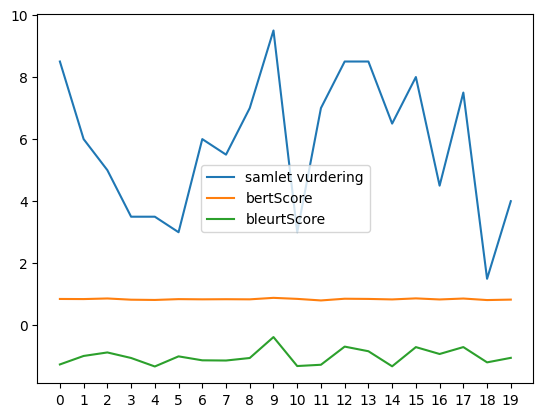

In [ ]:
def getSubredditFromPost(prompt):
    return  prompt.split('\r')[0][11:]

df = pd.read_csv("./case_studies/case_study_1_extended.csv")
df['samlet vurdering'] = [float(vurdering.replace(",", ".")) for vurdering in df['samlet vurdering']]

# Plot the scores to allow for easier examination
df[['samlet vurdering', 'bertScore', 'bleurtScore']].plot.line(xticks=range(20))

df = df[[getSubredditFromPost(prompt) == 'r/pettyrevenge' for prompt in df['prompt']]]

# Compuate the Pearson correlation coefficient between the human annotations and the metrics.
pearson_corr, _ = pearsonr(df['samlet vurdering'], df['bertScore'])
print("----- BERT -----")
print("Pearson r:", pearson_corr)

pearson_corr, _ = pearsonr(df['samlet vurdering'], df['bleurtScore'])
print("----- BLEURT -----")
print("Pearson r:", pearson_corr)

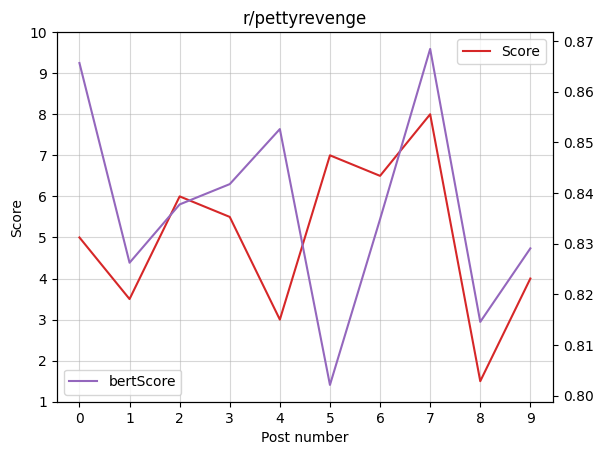

In [ ]:
# Plot the human annotations along side the BERT score with the human annotations on the left y-axis 
# and the BERT score on the right.

import matplotlib.pyplot as plt

df = pd.read_csv("./case_studies/case_study_1_extended.csv")
df['samlet vurdering'] = df['samlet vurdering'].str.replace(",", ".").astype(float)

df = df[df['prompt'].apply(
    lambda p: getSubredditFromPost(p) == 'r/pettyrevenge'
)].reset_index(drop=True)

ax = df.plot(y='samlet vurdering', color='tab:red', label='Score')
df.plot(y='bertScore', ax=ax.twinx(), color='tab:purple')
ax.set(
    title='r/pettyrevenge',
    xlabel='Post number',
    xticks=range(10),
    ylim=(1, 10),
    ylabel='Score'
)

ax.grid(True, alpha=0.5)
plt.show()

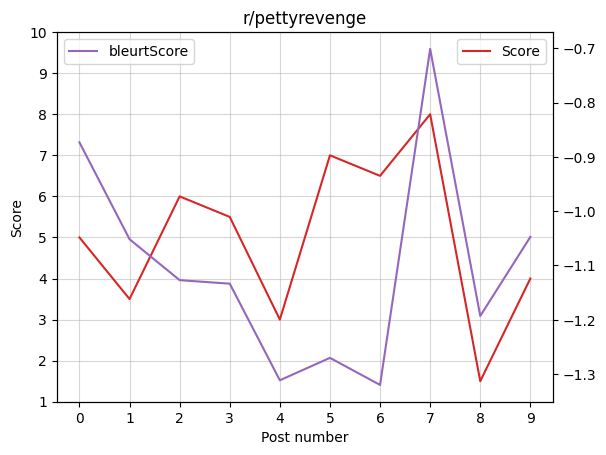

In [ ]:
# Plot the human annotations along side the BLEURT score with the human annotations on the left y-axis 
# and the BLEURT score on the right.

df = pd.read_csv("./case_studies/case_study_1_extended.csv")
df['samlet vurdering'] = df['samlet vurdering'].str.replace(",", ".").astype(float)

df = df[df['prompt'].apply(
    lambda p: getSubredditFromPost(p) == 'r/pettyrevenge'
)].reset_index(drop=True)

ax = df.plot(y='samlet vurdering', color='tab:red', label='Score')
df.plot(y='bleurtScore', ax=ax.twinx(), color='tab:purple')
ax.set(
    title='r/pettyrevenge',
    xlabel='Post number',
    xticks=range(10),
    ylim=(1, 10),   
    ylabel='Score'
)

ax.grid(True, alpha=0.5)
plt.show()

<h2> Case Study of Noir Bias </h2>

In [ ]:
# This piece of code chooses a random subset of summaries generated from the given models on the given subreddits.
import pandas as pd
from datasets import load_dataset

def getSubredditFromPost(prompt):
    return  prompt.split('\r')[0][11:]

posts = load_dataset("trl-lib/tldr")
summaries = pd.read_csv("./summaries.csv")
result = []

# Combine the summary, the post, the label in one file
for model in ['ainize/bart-base-cnn', 'google/pegasus-large', 'google-t5/t5-large', 'facebook/bart-large-cnn', 'Falconsai/text_summarization']:
    for subreddit in ["r/offmychest", 'r/BreakUps']:
        numberOfSamples = 4;
        sub_dataset = summaries[
            summaries["prompt"].apply(lambda p: getSubredditFromPost(p) == subreddit)
        ].sample(n=numberOfSamples)
        for i in range(numberOfSamples):
            prompt = sub_dataset.iloc[i]['prompt']
            summary = sub_dataset.iloc[i][model]
            title_start = prompt.find("TITLE:")
            title_end = prompt.find("\n", title_start);
            labels = posts['train'].filter(lambda row: prompt[title_start:title_end-2] in row['prompt'])['completion']
            if len(labels) != 1:
                print("ERROR")
                print(prompt[title_start:title_end])
            result.append({"model": model, "subreddit": subreddit, "prompt": prompt, "summary": summary, "label": labels[0]})

pd.DataFrame(result).to_csv("./case_studies/case_study_2.csv")

Pearson r: 0.5165514303034402


<Axes: >

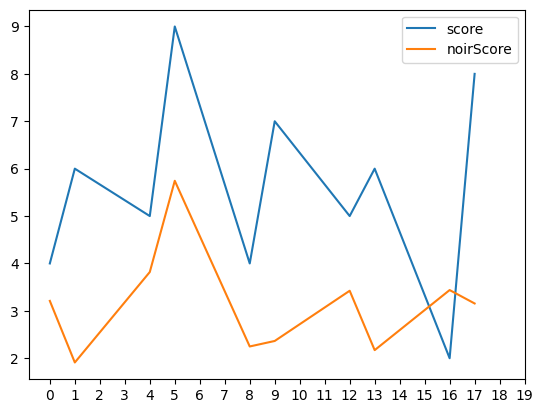

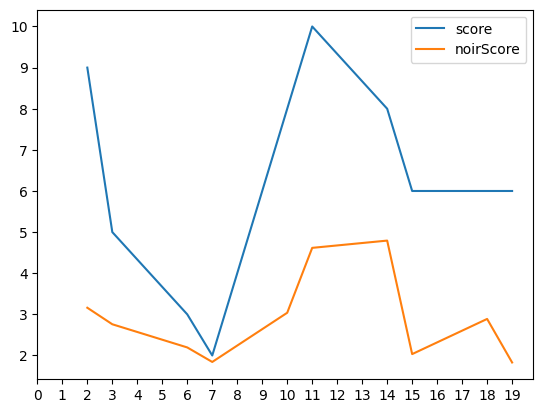

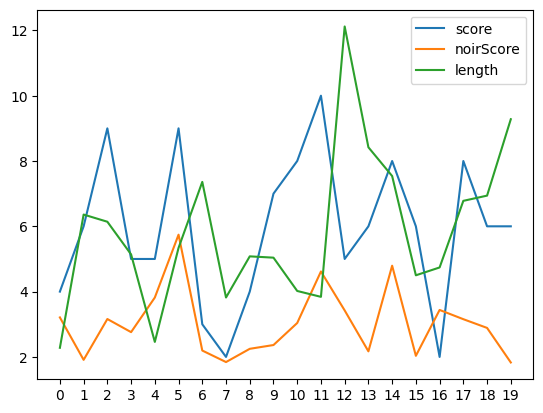

In [32]:
# Compute the scores of all the summaries and extend the file with these scores.
df = pd.read_csv("./case_studies/case_study_2.csv")
noirScores, bleurtScore, rougeScore, bertScore, bleuScore = compute_scores(df)
df.insert(len(df.columns), "noirScore", noirScores)
df.insert(len(df.columns), "bleurtScore", bleurtScore)
df.insert(len(df.columns), "rougeScore", rougeScore)
df.insert(len(df.columns), "bertScore", bertScore)
df.insert(len(df.columns), "bleuScore", bleuScore)
df.to_csv("./case_studies/case_study_2_extended.csv")

# Plot the data for each subreddit
df[df['subreddit']=='r/offmychest'][['score', 'noirScore']].plot.line(xticks=range(20))
df[df['subreddit']=='r/BreakUps'][['score', 'noirScore']].plot.line(xticks=range(20))

# Compute the Pearson correlation coefficient
pearson_corr, _ = pearsonr(df['score'], df['noirScore'])
print("Pearson r:", pearson_corr)

# Plot the length with the data to see correlation between score and summary length
df_with_len = df.copy()
df_with_len["length"] = [len(summary)/50 for summary in df_with_len['summary']]
df_with_len[['score', 'noirScore', 'length']].plot.line(xticks=range(20))

<h2>Case study of TIFU</h2>

In [ ]:
# Compute the score for all samples in the case study of r/tifu and save them to file
df = pd.read_csv("./case_studies/case_study_3.csv")
noirScores, bleurtScore, rougeScore, bertScore, bleuScore = compute_scores(df)
df.insert(len(df.columns), "noirScore", noirScores)
df.insert(len(df.columns), "bleurtScore", bleurtScore)
df.insert(len(df.columns), "rougeScore", rougeScore)
df.insert(len(df.columns), "bertScore", bertScore)
df.insert(len(df.columns), "bleuScore", bleuScore)
df.to_csv("./case_studies/case_study_3_extended.csv")

Token indices sequence length is longer than the specified maximum sequence length for this model (566 > 512). Running this sequence through the model will result in indexing errors


Pearson r: 0.31520815423611614


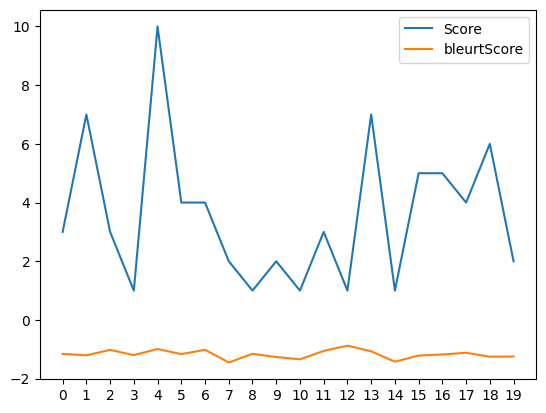

In [ ]:
# Plot the human annotations against the BLEURT score
df = pd.read_csv("./case_studies/case_study_3_extended.csv")
df[['Score', 'bleurtScore']].plot.line(xticks=range(20))

# Compute the Pearson correlation coefficient between the human annotations and the BLEURT score.
pearson_corr, _ = pearsonr(df['Score'], df['bleurtScore'])
print("Pearson r:", pearson_corr)

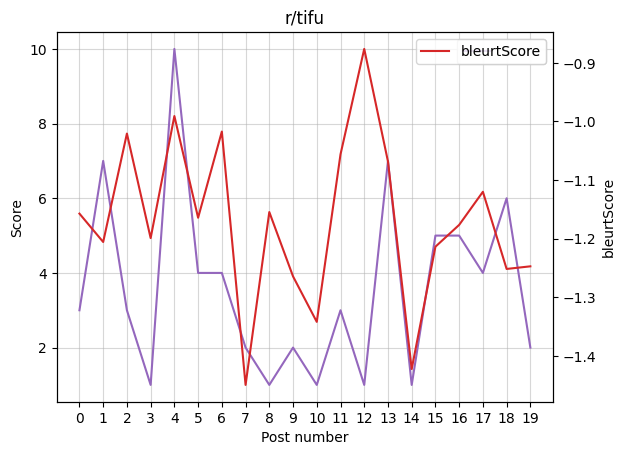

In [ ]:
# Plot the human annotations against the BLEURT score with different axis for the two scores
df = pd.read_csv("./case_studies/case_study_3_extended.csv")

ax = df.plot(y='Score', color='tab:purple', ylabel='Score')
df.plot(y='bleurtScore', ax=ax.twinx(), color='tab:red', ylabel='bleurtScore')

ax.set(
    xlabel='Post number',
    title='r/tifu',
    xticks=range(20)
)
ax.grid(True, alpha=0.5)

plt.show()

<h2>Relationships Analysis</h2>

In [ ]:
# Compute scores for the samples of the relationship analysis and save them to file.
df = pd.read_csv("./case_studies/case_study_5.csv")

noirScores, bleurtScore, rougeScore, bertScore, bleuScore = compute_scores(df)
df.insert(len(df.columns), "noirScore", noirScores)
df.insert(len(df.columns), "bleurtScore", bleurtScore)
df.insert(len(df.columns), "rougeScore", rougeScore)
df.insert(len(df.columns), "bertScore", bertScore)
df.insert(len(df.columns), "bleuScore", bleuScore)
df.to_csv("./case_studies/case_study_5_extended.csv")

BLEU SCORE
Pearson r: 0.16548646910464004
ROUGE SCORE
Pearson r: 0.19890715847807042


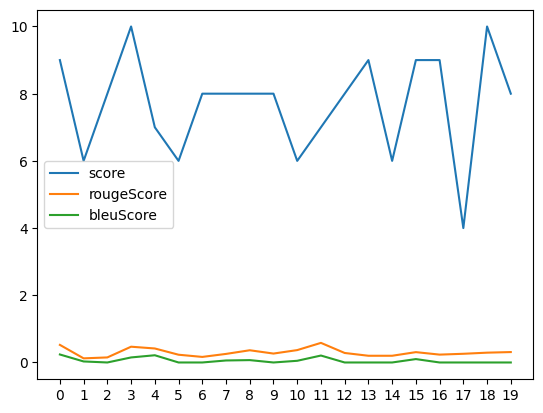

In [ ]:
# Plot the human anotations and the ROUGE and BLEU score against each other.
df = pd.read_csv("./case_studies/case_study_5_extended.csv")
df[['score', 'rougeScore', 'bleuScore']].plot.line(xticks=range(20))

# Compute the Pearson correlation coefficient between the metrics and the human annotations
print("BLEU SCORE")
pearson_corr, _ = pearsonr(df['score'], df['bleuScore'])
print("Pearson r:", pearson_corr)

print("ROUGE SCORE")
pearson_corr, _ = pearsonr(df['score'], df['rougeScore'])
print("Pearson r:", pearson_corr)

A note on the low Pearson correlation coefficient: The study showed a very low correlation in the changes in the scores of summaries in the relationship dataset. However, the scores for the metrics and the human annotations where in general very high. This means that the fluctuations in the scores might not correlate, but the human annotaters did agree with the metrics on the fact that the summaries in the subreddit "r/relationships" were very good. 

<h2>Case Study - looseit</h2>

In [ ]:
# Compute the scores for the samples of the looseit subreddit.
df = pd.read_csv("./case_studies/case_study_4.csv")
noirScores, bleurtScore, rougeScore, bertScore, bleuScore = compute_scores(df)
df.insert(len(df.columns), "noirScore", noirScores)
df.insert(len(df.columns), "bleurtScore", bleurtScore)
df.insert(len(df.columns), "rougeScore", rougeScore)
df.insert(len(df.columns), "bertScore", bertScore)
df.insert(len(df.columns), "bleuScore", bleuScore)
df.to_csv("./case_studies/case_study_4_extended.csv")

BLEU SCORE
Pearson r: 0.18531283599576379
ROUGE SCORE
Pearson r: 0.13129969880850267


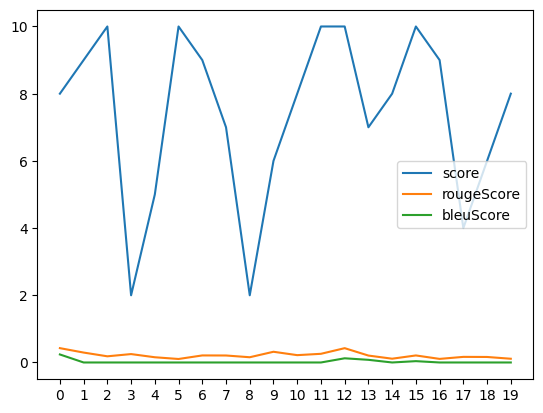

In [ ]:
# Plot the human annotations against the ROUGE and the BLEU score
df = pd.read_csv("./case_studies/case_study_4_extended.csv")
df[['score', 'rougeScore', 'bleuScore']].plot.line(xticks=range(20))

# Compute the Pearson correlation coefficient of the human annotations and the BLEU and ROUGE score
print("BLEU SCORE")
pearson_corr, _ = pearsonr(df['score'], df['bleuScore'])
print("Pearson r:", pearson_corr)

print("ROUGE SCORE")
pearson_corr, _ = pearsonr(df['score'], df['rougeScore'])
print("Pearson r:", pearson_corr)

<h1>Summary Lengths</h1>
The next part willl be computing the lengths of the summaries in the different subreddits to see if the length of the summaries are varying and could be affecting the quality of the summaries.

In [ ]:
summaries = pd.read_csv("./summaries.csv")

def getSubredditFromPost(prompt):
    return  prompt.split('\r')[0][11:]

#Find all subreddits in the data
subreddits = []
for post in summaries['prompt']:
    subreddit = getSubredditFromPost(post)
    if subreddit not in subreddits:
        subreddits.append(subreddit)

In [ ]:
# Compute the length of all posts, reference summaries and generated summaries and save it all to file.
posts = load_dataset("trl-lib/tldr")

summaries = pd.read_csv("./summaries.csv")

result = []

for model in ['ainize/bart-base-cnn', 'google/pegasus-large', 'google-t5/t5-large', 'facebook/bart-large-cnn', 'Falconsai/text_summarization']:
    for subreddit in subreddits:
        sub_dataset = summaries[
            summaries["prompt"].apply(lambda p: getSubredditFromPost(p) == subreddit)
        ]
        for i in range(len(sub_dataset)):
            prompt = sub_dataset.iloc[i]['prompt']
            summary = sub_dataset.iloc[i][model]
            title_start = prompt.find("TITLE:")
            title_end = prompt.find("\n", title_start);
            labels = posts['train'].filter(lambda row: prompt[title_start:title_end-2] in row['prompt'])['completion']
            if len(labels) != 1:
                if len(labels) != 2 or labels[0]!=labels[1]:
                    print("ERROR")
                    print(prompt[title_start:title_end])
            result.append({"model": model, "subreddit": subreddit, "prompt_length": len(prompt), "summary_length": len(summary), "label_length": len(labels[0])})

pd.DataFrame(result).to_csv("./case_studies/case_study_length.csv")

In [ ]:
# Compute the average length of posts, generated summaries, and reference summaries
all_lengths = pd.read_csv("./case_studies/case_study_length.csv")
subreddit_lengths = {}
for subreddit in subreddits:
    lengths = {}
    all_lengths_subreddit = all_lengths[all_lengths['subreddit'] == subreddit]
    
    prompt_length_subreddit = all_lengths_subreddit['prompt_length']
    lengths["avg_prompt_length"] = sum(prompt_length_subreddit)/len(prompt_length_subreddit)

    summary_length_subreddit = all_lengths_subreddit['summary_length']
    lengths["avg_summary_length"] = sum(summary_length_subreddit)/len(summary_length_subreddit)

    label_length_subreddit = all_lengths_subreddit['label_length']
    lengths["avg_label_length"] = sum(label_length_subreddit)/len(label_length_subreddit)

    subreddit_lengths[subreddit] = lengths

length_pd = pd.DataFrame(subreddit_lengths).transpose()
print("Average summary length: " + str(sum(all_lengths['summary_length'])/len(all_lengths['summary_length'])))
print("Average prompt length: " + str(sum(all_lengths['prompt_length'])/len(all_lengths['prompt_length'])))
print("Average label length: " + str(sum(all_lengths['label_length'])/len(all_lengths['label_length'])))


Average summary length: 293.5387174833636
Average prompt length: 1367.4370840895342
Average label length: 141.10768300060496


In [ ]:
# Plot the average length divided into subreddits
df_long = length_pd.reset_index().melt(
    id_vars="index",
    var_name="metric",
    value_name="value"
).rename(columns={"index": "subreddit"})

chart = alt.Chart(df_long).mark_line().encode(
    x=alt.X("subreddit:N", sort=None, title="Subreddit"),
    y=alt.Y("value:Q", title="Length"),
    color=alt.Color("metric:N", title="Metric"),
    tooltip=["subreddit", "metric", "value"]
).properties(
    width=900,
    height=400,
    title="Average Lengths by Subreddit"
)

chart.interactive()


<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


<h3>Notes for the length of the summaries</h3>
We can here see the average lengths of summaries, prompts and the reference summary. One finding from this data is that the length of the summaries is not affecting the low NOIR score of the subreddits "BreakUps" and "offmychest" as the length of these summaries are only around 3% longer than average. Additionaly, the length of the posts is around 5% longer, and there are multiple other subreddits that have longer summaries that does not suffer from their length. Therefore, the disadvantage of the summaries in these subreddits must come from other factors.